In [1]:
import numpy as np
import random as rnd
import pandas as pd
import string as str
from math import *

#scipy stat
import scipy.stats as ss
from scipy import stats
from scipy.stats import linregress,norm, kurtosis, moment,iqr,binom, binomtest,gmean
from scipy.stats import expon,zscore,zmap
from scipy.stats import t,ttest_ind
from scipy.stats import f,f_oneway
from scipy.stats import boxcox
from scipy.stats import pearsonr
#scipy signals library
from scipy import signal
#scipy calculus library
import scipy.integrate as spi
#scipy chi
from scipy.stats import chi,chi2_contingency,chi2


import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'

# Pkg import Date Time
import time
from datetime import datetime
from datetime import timedelta
from pandas.tseries.offsets import Hour, Minute
from pandas.tseries.offsets import Day, MonthEnd

import csv

# Graph Plot Packg
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.style as style
import seaborn as sns

###################################################
'''State-models'''
###################################################
# # Ordinary Least Squares
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.formula.api import ols
from statsmodels.stats.stattools import durbin_watson
from patsy import dmatrices
from statsmodels.stats.outliers_influence import OLSInfluence
###################################################
'''sciket-learn'''
###################################################
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OrdinalEncoder,OneHotEncoder
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.linear_model import SGDClassifier
from sklearn.model_selection import cross_val_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import KFold, cross_val_score
from sklearn.model_selection import StratifiedKFold
from zlib import crc32
import hashlib

###################################################
'''scikit-lern Data Set'''
###################################################
from sklearn.datasets import fetch_openml
from sklearn.datasets import make_blobs
from sklearn import datasets
from sklearn.datasets import load_iris

###################################################
'''Tenser flow packeges'''
###################################################
#import tensorflow as tf
#from tensorflow import keras

###################################################
'''Miscellaneous'''
###################################################
import tarfile
import urllib.request

import sys
# caution: path[0] is reserved for script path (or '' in REPL)
sys.path.insert(1, r'C:\Users\TODO\Desktop\Abhi\AI\AI\Math\Hands-On\statemodelsStudy')
from olsRegressionAnalysis import dispAnalysisOfVariance, tableDispFormatt,getInvOfProductMat,\
                                  getRegressionEqn,\
                                  dispReghressionAnalysis,norm_scalling,getCorrelation,\
                                  get_variance_inflation_factors

In [2]:
path = r'C:\Users\TODO\Desktop\Abhi\AI\AI\allDataSet\bOOK-DataSet\DeliveryTimeData.txt'
df = pd.read_csv(path)
df.columns

Index(['Obs', 'DlvrTime_Y', 'NumCase_X1', 'Dist_X2'], dtype='object')

### Statemodels Linears


In [3]:
formula = 'DlvrTime_Y ~ NumCase_X1 + Dist_X2'
y, X = dmatrices(
                 formula_like = formula, 
                 data=df,
                 return_type='dataframe'
                 )

# 3. Model fit and summary
mod = sm.OLS(y, X)    # Describe model
res = mod.fit()       # Fit model
print(res.summary())

                            OLS Regression Results                            
Dep. Variable:             DlvrTime_Y   R-squared:                       0.960
Model:                            OLS   Adj. R-squared:                  0.956
Method:                 Least Squares   F-statistic:                     261.2
Date:                Sat, 04 Oct 2025   Prob (F-statistic):           4.69e-16
Time:                        21:38:20   Log-Likelihood:                -63.415
No. Observations:                  25   AIC:                             132.8
Df Residuals:                      22   BIC:                             136.5
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      2.3412      1.097      2.135      0.0

### Scattered Data ANOVAL Analysis

In [4]:
test_class = OLSInfluence(res) # to calculate R sqr predict & Press statices
                               # small press statices would be prefer
dfCoff = pd.DataFrame({'coff':res.params,
                       'se err':res.bse,
                       'ci_l':res.conf_int().loc[:,0],
                       'ci_u':res.conf_int().loc[:,1]
                       },
                      index=res.params.index)
dfANOVA = pd.DataFrame({
                         'anova': [res.nobs,res.df_model,res.df_resid,res.ssr,res.ess,res.mse_resid,
                                   res.mse_model,res.llf,res.rsquared,res.rsquared_adj,\
                                   1 - (test_class.ess_press/(res.ssr + res.ess)),test_class.ess_press]                    
                       },
                                 index=['Obs','DoFRegressors','DoFResiduals','SSres','SSr','MSres','MSr','logLike','r_sqr','r_sqr_adj',
                                        'r_sqr_predt','PRESS'])

print(dfANOVA)
print(dfCoff)





                     anova
Obs              25.000000
DoFRegressors     2.000000
DoFResiduals     22.000000
SSres           233.731677
SSr            5550.810923
MSres            10.624167
MSr            2775.405461
logLike         -63.414688
r_sqr             0.959594
r_sqr_adj         0.955920
r_sqr_predt       0.920644
PRESS           459.039315
                coff    se err      ci_l      ci_u
Intercept   2.341231  1.096730  0.066752  4.615710
NumCase_X1  1.615907  0.170735  1.261825  1.969990
Dist_X2     0.014385  0.003613  0.006892  0.021878


### F-Sate Test alfa = 0.05

In [5]:
nullHypo = []
alfa = 0.05
conclusions = False
print('Model F Sate: ',res.fvalue)
print('F - p Val   : ',res.f_pvalue, '  ===> is p val < alfa(0.05): ',res.f_pvalue < alfa)
if(res.f_pvalue < alfa):
    nullHypo.append('Reject Null hypothesis')
else:
    nullHypo.append('Fail to Reject Null hypothesis')

f_sigs_lvl = f.isf(q = 0.05, dfn = res.df_model,dfd = res.df_resid, loc=0, scale=1)
print('F - Sig     : ',f_sigs_lvl,'   ========> is Models F-Score > F-sig levels:  ',res.fvalue > f_sigs_lvl)
if(res.fvalue > f_sigs_lvl):
    nullHypo.append('Reject Null hypothesis')
    conclusions = True
else:
    nullHypo.append('Fail to Reject Null hypothesis')

if(nullHypo[0] == nullHypo[0]):
    print(nullHypo[0])
else:
    raise Exception("Both Null hypthesis check not matched eatch others!!!")

if conclusions == True:
    print('Altest one regressor\n \
           Play Importent role in\n \
           model. So we can conclude\n \
           dependent variable \'Y\' dependent\n \
           atlest one regressosr variable'
           )
else:
    print('We have sufficient evidance  that\n \
           Not!!! any regressor variable\n \
           paly significance roll in models\n \
           in other word can say \'Y\' not\n \
           depend any regressors variable.')

Model F Sate:  261.23510866056375
F - p Val   :  4.687422207749719e-16   ===> is p val < alfa(0.05):  True
F - Sig     :  3.4433567793667237    ========> is Models F-Score > F-sig levels:   True
Reject Null hypothesis
Altest one regressor
            Play Importent role in
            model. So we can conclude
            dependent variable 'Y' dependent
            atlest one regressosr variable


### T-STAT Test

In [6]:
idx = res.params.index.values.tolist()
t_score = []
p_val = []
nullHypothesisCheck = []
nulHypothjesisStatus = []
t_significance = []
alfa = 0.05
sigf = t.isf(q = 0.05/2.0, df = res.df_resid, loc=0, scale=1)
for i in np.arange(0,len(idx),1):
    T = np.zeros(len(idx),dtype=int)
    T[i] = 1
    ret = res.t_test(T)
    hypotheses = idx[i] + ' = ' + ' 0 '
    ret = res.t_test(hypotheses)
    t_score.append(ret.tvalue[0,0])
    
    # null hypothesis checking by using p values
    p_val.append(ret.pvalue) # p value from two tailed test
    nullHypothesisCheck.append(ret.pvalue < alfa)
    if(ret.pvalue < alfa):
        nulHypothjesisStatus.append('Reject null hypothesis')
    else:
        nulHypothjesisStatus.append('Fail to Reject null hypothesis')
    
    # null hypothesis checking by using significance lavel of t score
    t_significance.append(abs(ret.tvalue[0,0]) > sigf) #div by 2, two tailed test    

dfTstate = pd.DataFrame({
    'T_STAT':res.tvalues,
    'p val' :p_val,
    '|t|<p':nullHypothesisCheck,
    '|t|<sig':t_significance,
    'Conclude':nulHypothjesisStatus
       
}, index = res.tvalues.index.values)
if dfTstate['|t|<p'].equals(dfTstate['|t|<sig']) != True:
    raise Exception("Something error in t-sig & calculated p value!!!")
dfTstate    
    

,T_STAT,p val,|t|<p,|t|<sig,Conclude
Intercept,2.134738,0.04417012415675511,True,True,Reject null hypothesis
NumCase_X1,9.464421,3.2549315736656197e-09,True,True,Reject null hypothesis
Dist_X2,3.981313,0.0006312468622429184,True,True,Reject null hypothesis


### Scatter Matrix



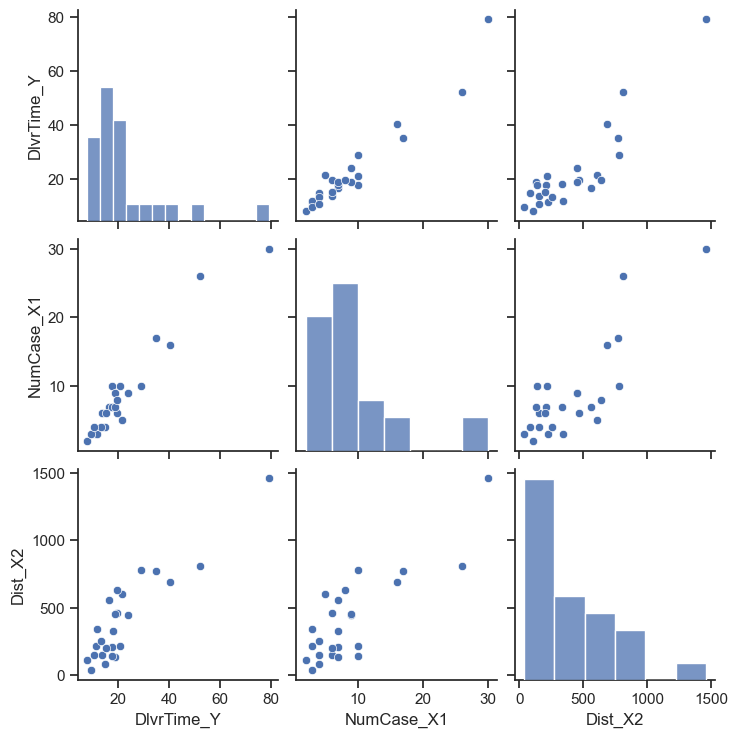

In [7]:
sns.set_theme(style="ticks")
dfSeborn = df.drop(['Obs'],axis = 'columns')
sns.pairplot(data = dfSeborn)


### Covariance analysis

In [8]:
dfCov = df.drop(['Obs'],axis = 'columns')
corr = dfCov.corr(method='pearson')
print(corr)

            DlvrTime_Y  NumCase_X1   Dist_X2
DlvrTime_Y    1.000000    0.964615  0.891670
NumCase_X1    0.964615    1.000000  0.824215
Dist_X2       0.891670    0.824215  1.000000


### Extra Sum of square

#### Let i want to calcualte:
1. effect of NumCase_X1 when Dist_X2 already given in models
2. effect of Dist_X2 when NumCase_X1 already given
3. Keep your regressor variable in full models
   and remove your regressor variable form redused models
4. F-State = (Squarte sum of regressor due to Dist_X2 when NumCase_X1 already given in models)/num of group redused mopdels
   F-Score = F-state/Mean squasre sum of regressor
                

In [9]:
# 1. effect of Dist_X2 when NumCase_X1 already given in models
# All params due to compleate models
fm_formula = 'DlvrTime_Y ~ NumCase_X1 + Dist_X2'
rm_formula = 'DlvrTime_Y ~ NumCase_X1'
num_of_grop_in_rm = 1


dfExtraSumSqr = pd.DataFrame({})
def getStatus(x,y):
    if x > y:
        return 'Decrease'
    elif (x < y):
        return 'Increse'
    else:
        return 'Not effect'
y, X = dmatrices(
                 formula_like = fm_formula, 
                 data=df,
                 return_type='dataframe'
                 )

# 3. Model fit and summary
mod = sm.OLS(y, X)    # Describe model
fm = mod.fit()       # fm = full modlesl
SSres_fm = fm.ssr
MSres_fm = fm.mse_model
SSr_fm   = fm.ess
MSr_fm   = fm.mse_resid
dfExtraSumSqr['fm'] = [SSres_fm, MSres_fm, SSr_fm, MSr_fm]
dfExtraSumSqr.index = ['ssres','msres','ssr','msr']
# params due to redused models
y, X = dmatrices(
                 formula_like = rm_formula, 
                 data=df,
                 return_type='dataframe'
                 )

# 3. Model fit and summary
mod = sm.OLS(y, X)    # Describe model
rm = mod.fit()       # fm = full modlesl
SSres_rm = rm.ssr
MSres_rm = rm.mse_model
SSr_rm   = rm.ess
MSr_rm   = rm.mse_resid
dfExtraSumSqr['rm'] = [SSres_rm, MSres_rm, SSr_rm, MSr_rm]
dfExtraSumSqr['fm-rm'] = dfExtraSumSqr['fm'] - dfExtraSumSqr['rm']
dfExtraSumSqr['Status'] = dfExtraSumSqr.apply(lambda x: getStatus(x['fm'],x['rm']),axis='columns')
# Check Mean square err or Sum of square err b/w full models & redused models
print(dfExtraSumSqr)
# Calculate F-Score
# Step 4: Calculate F score
F = (dfExtraSumSqr.loc['ssr','fm-rm']/num_of_grop_in_rm)/dfExtraSumSqr.loc['msr','fm']
f_sigs_lvl_rm = f.isf(q = 0.05, dfn = num_of_grop_in_rm,dfd = res.df_resid, loc=0, scale=1)
print('redused modles F-Score: ',F, ' F-sig due to redused models: ',f_sigs_lvl_rm)
if( F > f_sigs_lvl_rm):
    print('Reject Null hypothesis')
    txt = 'Find effect due to \'Dist_X2\' when \'NumCase_X1\'\n \
    already given. H0 => Dist_X2 = 0, contribute significance\n\
    roll in models'
    print(txt)
else: 
    print('Failk to reject null hypothesis')
    txt = 'Find effect due to \'Dist_X2\' when \'NumCase_X1\'\n \
    already given. H0 => Dist_X2 = 0, Not contribute significance\n\
    roll in models'
    print(txt)


                fm           rm        fm-rm    Status
ssres   233.731677   402.133803  -168.402126   Increse
msres  2775.405461  5382.408797 -2607.003336   Increse
ssr    5550.810923  5382.408797   168.402126  Decrease
msr      10.624167    17.484078    -6.859911   Increse
redused modles F-Score:  15.850854292803023  F-sig due to redused models:  4.300949501777657
Reject Null hypothesis
Find effect due to 'Dist_X2' when 'NumCase_X1'
     already given. H0 => Dist_X2 = 0, contribute significance
    roll in models


### Genral linear hypothesis test i.e. Tβ = 0

#### F- Score

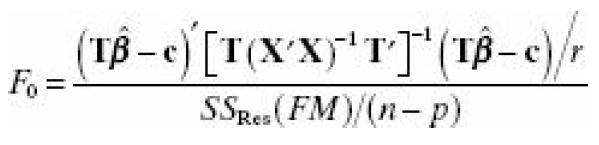

#### In Genral linear null hypothesis are

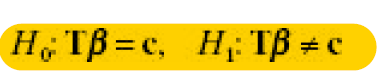

#### Then T & C are

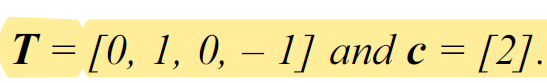

#### if c = 0 then Null hypothesis are H0: Tβ = 0

#### Rejections of NULL hypothesis

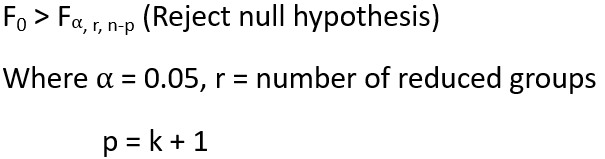


In [10]:
#Let null hypothesis ==> 
# NumCase_X1 - Dist_X2 = 2
# T matrix = [0,1,-1] & c= 2
eqn = 'NumCase_X1 - Dist_X2 = 2'
T = np.array([0,1,-1]).reshape(1,3)
number_of_gp_in_rm = 2
c = 2
cofficient = res.params.to_numpy().reshape(3,1)  
formula = 'DlvrTime_Y ~ NumCase_X1 + Dist_X2'
y, X = dmatrices(
                 formula_like = formula, 
                 data=df,
                 return_type='matrix'
                 )
f1 = np.transpose(np.dot(T,cofficient) - c)
f2 = np.linalg.inv(np.dot(np.dot(T,np.linalg.inv(np.dot(np.transpose(X),X))),np.transpose(T)))
f3 = np.dot(T,cofficient) - c
f4 = np.dot(np.dot(f1,f2),f3)
f4 = f4/number_of_gp_in_rm
f5 = (res.ssr/res.df_resid)
F0 = f4/f5
f_Sig = f.isf(q = 0.05, dfn = number_of_gp_in_rm,dfd = res.df_resid, loc=0, scale=1)
print(F0,f_Sig)
if (F0 > f_Sig):
    print('Reject Null hypothesis')
else:
    print('Fail to Reject Null hypothesis!!!.')
    print('i.e. ',eqn, ' Not hold true')


[[2.63059258]] 3.4433567793667237
Fail to Reject Null hypothesis!!!.
i.e.  NumCase_X1 - Dist_X2 = 2  Not hold true


### CI plots

### Anolomy Detections
#### 1. Avrage variance of residuals [Must be const]
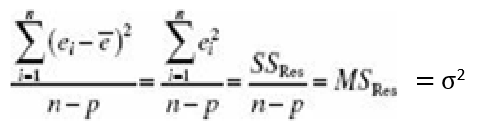
#### variance of the ith residual is
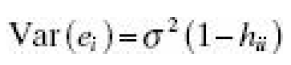

In [11]:
h_bar = 2 * (res.df_model + 1) / res.nobs
infl = res.get_influence()
student = infl.summary_frame()
hat_diag = infl.summary_frame()['hat_diag']

var_ei = res.mse_resid * (1 - hat_diag)
x_axis = np.linspace(1,2,var_ei.size)
#sns.scatterplot(x = x_axis, y = var_ei, hue=var_ei)
#print(student)


### Pure Err, lack of test

### PE Near-Neighbors test for Multi-regressions

### Goodness Of Fit

### PP-PLOT
### QQ-PLOT
### PQ-PLOT